# Phase 2 - Engineer & Transform Features

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/cleaned/cleaned_titanic.csv")
print("Shape:", df.shape)
print(df.head())

Shape: (891, 8)
   Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0         0       3    male  22.0      1      0   7.2500        S
1         1       1  female  38.0      1      0  65.6344        C
2         1       3  female  26.0      0      0   7.9250        S
3         1       1  female  35.0      1      0  53.1000        S
4         0       3    male  35.0      0      0   8.0500        S


We load the cleaned Titanic dataset from Phase 1. All missing values, duplicates, and outliers were already handled there. Sex and Embarked are still text — we encode them in this notebook.

## One-Hot Encode Categorical Columns

In [2]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
print(df.head())

   Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  \
0         0       3  22.0      1      0   7.2500      True       False   
1         1       1  38.0      1      0  65.6344     False       False   
2         1       3  26.0      0      0   7.9250     False       False   
3         1       1  35.0      1      0  53.1000     False       False   
4         0       3  35.0      0      0   8.0500      True       False   

   Embarked_S  
0        True  
1       False  
2        True  
3        True  
4        True  


**Why one-hot?** Sex and Embarked are *nominal* (no natural order). Label encoding (0, 1, 2) would imply Queenstown > Cherbourg, which is meaningless. One-hot creates separate binary columns for each category. We use `drop_first=True` to avoid multicollinearity — if Sex_male is 0, the passenger is female (no need for a Sex_female column). Same logic for Embarked: we keep Embarked_Q and Embarked_S, with Cherbourg as the baseline.

## Ordinal Encoding — Pclass

In [3]:
# Pclass already has natural order: 1 (best) > 2 > 3 (worst)
# No transformation needed — it's already ordinal encoded
print(df['Pclass'].value_counts().sort_index())

Pclass
1    216
2    184
3    491
Name: count, dtype: int64


**Why ordinal is OK here:** 1st class > 2nd class > 3rd class. The order matters and the numbers reflect it, so we leave Pclass as-is. No transformation needed — it's already naturally ordinal encoded.

## Scale Numerical Columns

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Age_scaled', 'Fare_scaled']] = scaler.fit_transform(df[['Age', 'Fare']])
print(df[['Age', 'Age_scaled', 'Fare', 'Fare_scaled']].head())

    Age  Age_scaled     Fare  Fare_scaled
0  22.0   -0.534891   7.2500    -0.820552
1  38.0    0.668392  65.6344     2.031623
2  26.0   -0.234070   7.9250    -0.787578
3  35.0    0.442776  53.1000     1.419297
4  35.0    0.442776   8.0500    -0.781471


**StandardScaler** converts Age and Fare so they have mean ~0 and standard deviation ~1. This is important because many ML models (like logistic regression, SVM, KNN) are sensitive to the scale of features — without scaling, Fare (0–65) would dominate over Age (0–80) just because of different ranges.

## Domain Feature 1: FamilySize

In [5]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
print(df['FamilySize'].value_counts().sort_index())

FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64


Created by adding SibSp (siblings/spouse) + Parch (parents/children) + 1 (the passenger). Solo travelers (FamilySize = 1) make up the majority. This captures the idea that family size might affect survival — large families may have struggled to stay together during evacuation.

## Domain Feature 2: FarePerPerson

In [6]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize'].replace(0, 1)
print(df['FarePerPerson'].head())

0     3.6250
1    32.8172
2     7.9250
3    26.5500
4     8.0500
Name: FarePerPerson, dtype: float64


**Why?** A family of 5 paying $50 total is different from 1 person paying $50. This normalizes fare by group size to get a per-person cost. We use `.replace(0, 1)` as a safety net to avoid division by zero (though FamilySize should always be at least 1).

## Interaction Feature: Class_Fare

In [7]:
df['Class_Fare'] = df['Pclass'] * df['Fare']
print(df['Class_Fare'].head())

0    21.7500
1    65.6344
2    23.7750
3    53.1000
4    24.1500
Name: Class_Fare, dtype: float64


**Why?** A 1st class passenger with a high fare is very different from a 3rd class passenger with a high fare. Multiplying Pclass by Fare captures that combination — it creates a single number that reflects both class and spending level together.

## Log-Transform Skewed Column

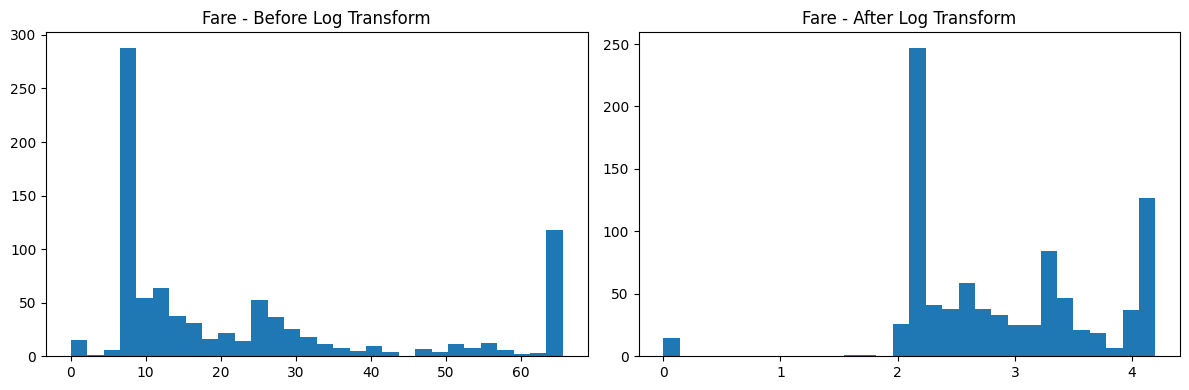

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Fare'], bins=30)
plt.title('Fare - Before Log Transform')

df['Fare_log'] = np.log1p(df['Fare'])

plt.subplot(1, 2, 2)
plt.hist(df['Fare_log'], bins=30)
plt.title('Fare - After Log Transform')
plt.tight_layout()
plt.show()

Fare is heavily right-skewed (most fares are low, a few are very high). `np.log1p` applies `log(1 + x)` which compresses the long tail and makes the distribution more bell-shaped. **Why `log1p` not `log`?** `log(0)` crashes, but `log1p(0) = 0` — it handles zero fares safely. The side-by-side histograms show the before/after difference.

## Bin Age into Groups

In [9]:
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child', 'Teen', 'YoungAdult', 'Adult', 'Senior'])
print(df['AgeGroup'].value_counts())

AgeGroup
YoungAdult    514
Adult         216
Teen           70
Child          69
Senior         22
Name: count, dtype: int64


Instead of treating age as a continuous number, we group passengers into life stages: Child (0–12), Teen (13–18), YoungAdult (19–35), Adult (36–60), Senior (61+). This can help models that struggle with non-linear age effects — for example, children had higher survival priority ("women and children first").

## Save Engineered Features

In [10]:
df.to_csv("data/cleaned/titanic_features.csv", index=False)
print("Saved! Shape:", df.shape)
print("Columns:", list(df.columns))

Saved! Shape: (891, 16)
Columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Age_scaled', 'Fare_scaled', 'FamilySize', 'FarePerPerson', 'Class_Fare', 'Fare_log', 'AgeGroup']


Saving the final DataFrame with all new features to `data/cleaned/titanic_features.csv` so we can use it in the next phases (EDA, modeling) without re-running all the feature engineering steps.